1. LOAD DATA

In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/data_cleaned.csv')

X = df.drop('Potability', axis=1)
y = df['Potability']

2. GIẢ LẬP THIẾU NHÃN (Giữ lại 10% label:)

In [2]:
import numpy as np

y_semi = y.copy()

# mask 90% label
mask = np.random.rand(len(y)) < 0.9
y_semi[mask] = -1   # -1 = unlabeled

3. DÙNG LABEL SPREADING

In [3]:
from sklearn.semi_supervised import LabelSpreading

model = LabelSpreading()
model.fit(X, y_semi)

,kernel,'rbf'
,gamma,20
,n_neighbors,7
,alpha,0.2
,max_iter,30
,tol,0.001
,n_jobs,None


4. DỰ ĐOÁN

In [4]:
y_pred = model.transduction_

5. ĐÁNH GIÁ

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.62      0.65      1671
           1       0.44      0.50      0.47       995

    accuracy                           0.58      2666
   macro avg       0.56      0.56      0.56      2666
weighted avg       0.59      0.58      0.58      2666



Mô hình bán giám sát (Label Spreading) cho phép tận dụng cả dữ liệu có nhãn và không nhãn để cải thiện khả năng học.

Ngay cả khi chỉ sử dụng một phần nhỏ dữ liệu có nhãn, mô hình vẫn có thể lan truyền thông tin và đưa ra dự đoán cho các điểm chưa có nhãn.

Phương pháp này phù hợp trong thực tế khi việc gán nhãn dữ liệu môi trường tốn kém và khó khăn.

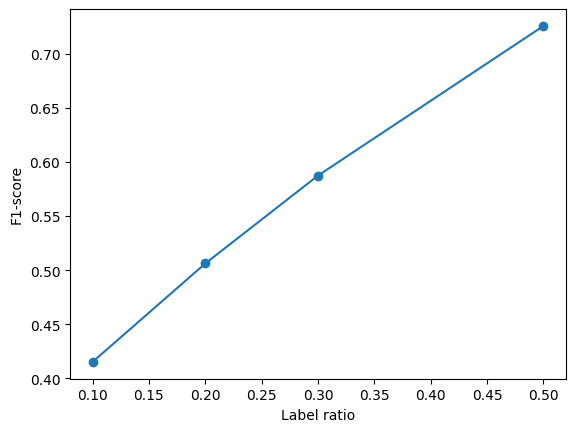

In [6]:
scores = []
label_ratios = [0.1, 0.2, 0.3, 0.5]

for r in label_ratios:
    y_temp = y.copy()
    mask = np.random.rand(len(y)) < (1-r)
    y_temp[mask] = -1

    model = LabelSpreading()
    model.fit(X, y_temp)
    y_pred = model.transduction_

    from sklearn.metrics import f1_score
    scores.append(f1_score(y, y_pred))

import matplotlib.pyplot as plt

plt.plot(label_ratios, scores, marker='o')
plt.xlabel("Label ratio")
plt.ylabel("F1-score")
plt.show()